# Machine Learning Project

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
!pip install xgboost

#Setting
pd.set_option ('display.max_columns', None)
sns.set_style('whitegrid')

In [ ]:
from google.colab import files
uploaded= files.upload()

Saving synthetic_dataset_10000x20.csv to synthetic_dataset_10000x20.csv


In [ ]:
import pandas as pd

df = pd.read_csv('synthetic_dataset_10000x20.csv')
df.head()

,customer_id,age,income,savings,monthly_expenses,num_dependents,credit_score,loan_amount,loan_term_months,employment_years,...,education,marital_status,region,recent_default,has_credit_card,signup_date,signup_dayofweek,debt_to_income,sin_age,target_default_risk
0,CUST006253,30,66737.0,11155.0,2272.0,2,605.076204,26965.0,48,3.9,...,HS,Single,West,1,1,2020-07-05,6,0.404,0.141120,1
1,CUST004685,22,70740.0,997.0,1934.0,1,683.291967,4681.0,36,0.7,...,Bachelors,Married,East,0,0,2018-10-03,2,0.066,0.808496,1
2,CUST001732,68,38890.0,1929.0,1696.0,0,658.003360,12633.0,72,2.2,...,Bachelors,Single,East,0,1,2018-05-30,2,0.325,0.494113,0
3,CUST004743,49,29049.0,6284.0,2485.0,1,707.477864,20881.0,36,2.7,...,HS,Married,South,0,1,2018-04-22,6,0.719,-0.982453,0
4,CUST004522,74,60063.0,924.0,3179.0,2,564.768511,19438.0,36,10.3,...,Masters,Single,West,0,0,2019-12-03,1,0.324,0.898708,1


# Perform EDA (Exploratory Data Analysis)

In [ ]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_id          10000 non-null  object 
 1   age                  10000 non-null  int64  
 2   income               9682 non-null   float64
 3   savings              9689 non-null   float64
 4   monthly_expenses     9675 non-null   float64
 5   num_dependents       10000 non-null  int64  
 6   credit_score         9674 non-null   float64
 7   loan_amount          10000 non-null  float64
 8   loan_term_months     10000 non-null  int64  
 9   employment_years     10000 non-null  float64
 10  home_ownership       10000 non-null  object 
 11  education            10000 non-null  object 
 12  marital_status       10000 non-null  object 
 13  region               10000 non-null  object 
 14  recent_default       10000 non-null  int64  
 15  has_credit_card      10000 non-null  

,age,income,savings,monthly_expenses,num_dependents,credit_score,loan_amount,loan_term_months,employment_years,recent_default,has_credit_card,signup_dayofweek,debt_to_income,sin_age,target_default_risk
count,10000.000000,9682.000000,9689.000000,9675.000000,10000.000000,9674.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,45.861600,59712.871411,5039.922489,2082.209612,1.214200,650.155438,16214.796900,45.642000,5.39701,0.047000,0.694800,3.011900,0.358156,-0.100387,0.513200
std,16.457987,39865.231489,5041.793583,1385.991787,1.108982,69.918297,16081.646814,15.475134,3.41370,0.211649,0.460515,2.003986,0.302606,0.667428,0.499851
min,18.000000,20001.000000,0.000000,200.000000,0.000000,363.077116,1000.000000,12.000000,0.00000,0.000000,0.000000,0.000000,0.004000,-0.999923,0.000000
25%,32.000000,31300.500000,1476.000000,1471.000000,0.000000,602.189895,8508.500000,36.000000,2.70000,0.000000,0.000000,1.000000,0.132000,-0.756802,0.000000
50%,46.000000,47301.500000,3499.000000,2007.000000,1.000000,649.808322,15174.500000,48.000000,5.10000,0.000000,1.000000,3.000000,0.275000,-0.157746,1.000000
75%,60.000000,75164.250000,6986.000000,2557.000000,2.000000,697.537432,21843.750000,60.000000,7.70000,0.000000,1.000000,5.000000,0.508000,0.515501,1.000000
max,74.000000,402769.000000,44644.000000,28664.000000,7.000000,850.000000,441190.000000,72.000000,21.50000,1.000000,1.000000,6.000000,2.031000,0.973848,1.000000


# Numeric Feature distrubution how each column behaves before modeling, picking number based columns for Study

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'income'}>,
        <Axes: title={'center': 'savings'}>,
        <Axes: title={'center': 'monthly_expenses'}>],
       [<Axes: title={'center': 'num_dependents'}>,
        <Axes: title={'center': 'credit_score'}>,
        <Axes: title={'center': 'loan_amount'}>,
        <Axes: title={'center': 'loan_term_months'}>],
       [<Axes: title={'center': 'employment_years'}>,
        <Axes: title={'center': 'recent_default'}>,
        <Axes: title={'center': 'has_credit_card'}>,
        <Axes: title={'center': 'signup_dayofweek'}>],
       [<Axes: title={'center': 'debt_to_income'}>,
        <Axes: title={'center': 'sin_age'}>,
        <Axes: title={'center': 'target_default_risk'}>, <Axes: >]],
      dtype=object)

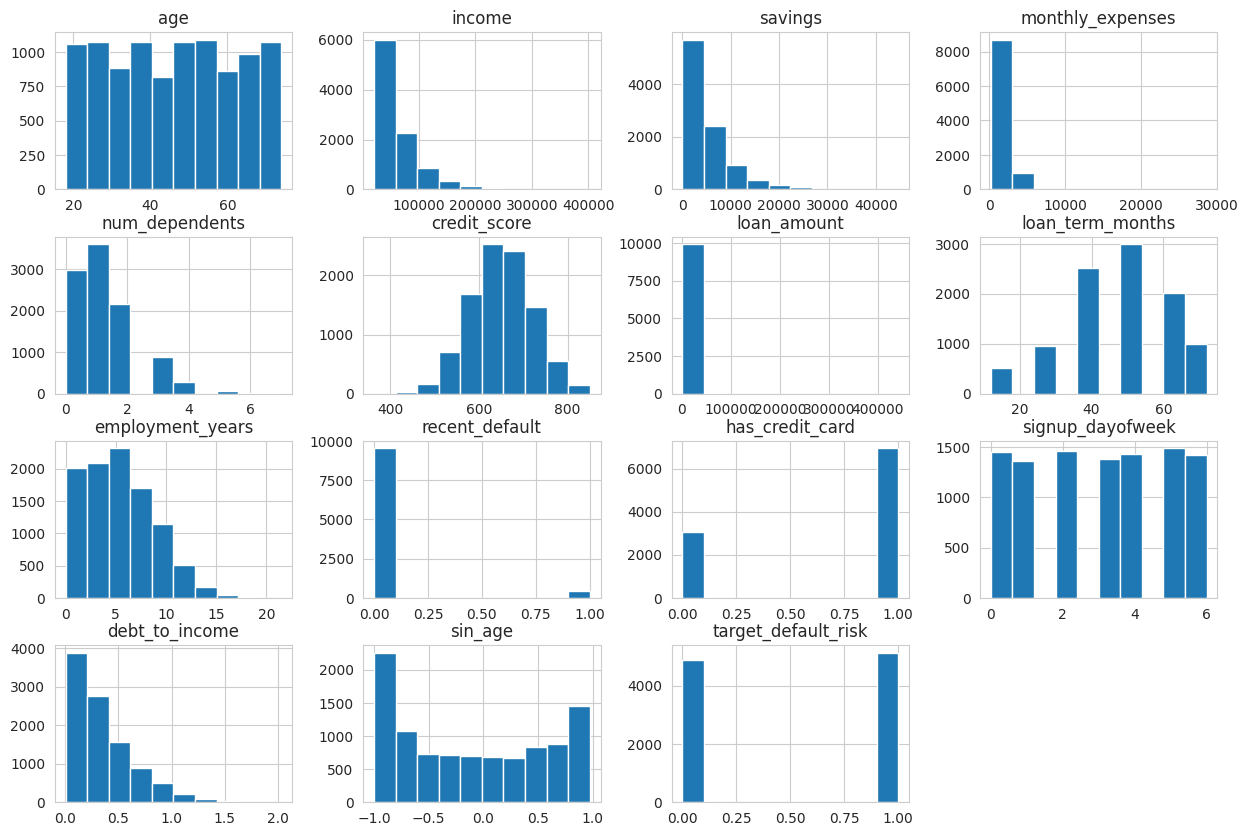

In [ ]:
# pick only number based column from the database
num_cols = df.select_dtypes(include=np.number).columns
# draw a distribution column for all the numbers
df[num_cols].hist(figsize=(15,10))

#Findings from the Data above
1- Numeric features such as income, savings, and loan_amount show strong right skewness, indicating presence of outliers.
2- Features like age and credit_score are normally distributed and suitable for modeling.
3- Binary variables such as has_credit_card and target_default_risk are correctly structured.
4- Outlier treatment and scaling will be required before modeling.

# Outlier Detection (Boxplot)- Show exact outliers clearly (dots outside box)

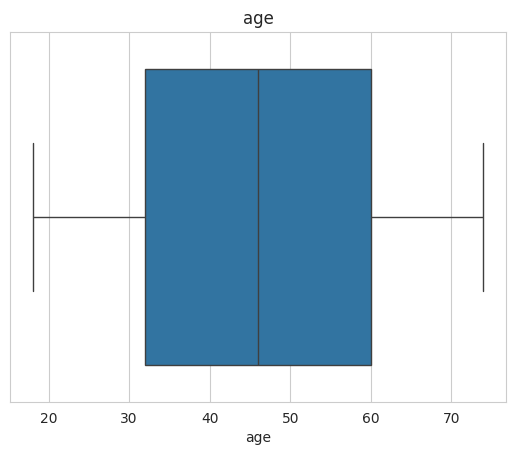

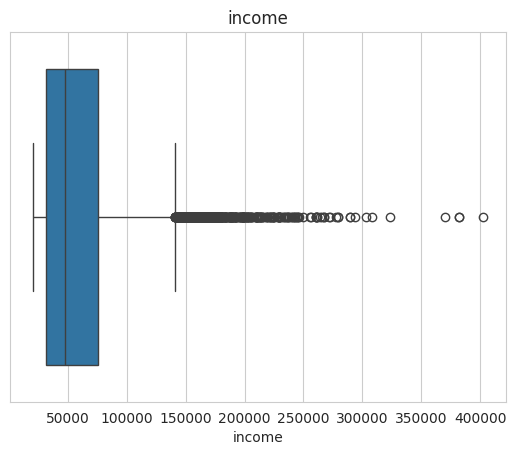

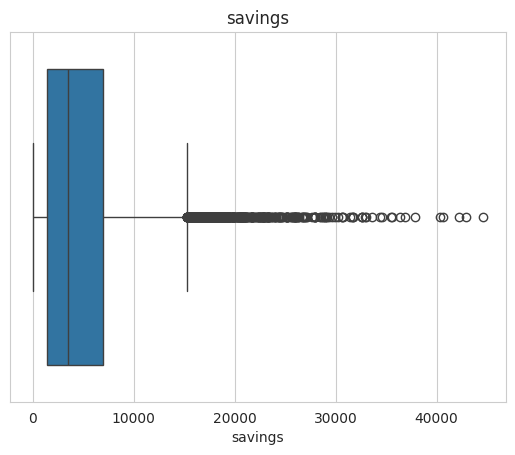

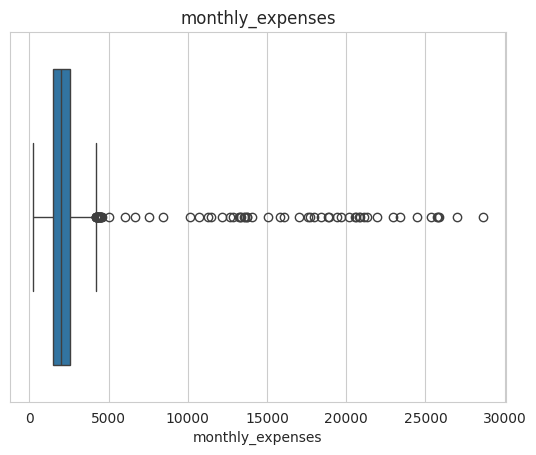

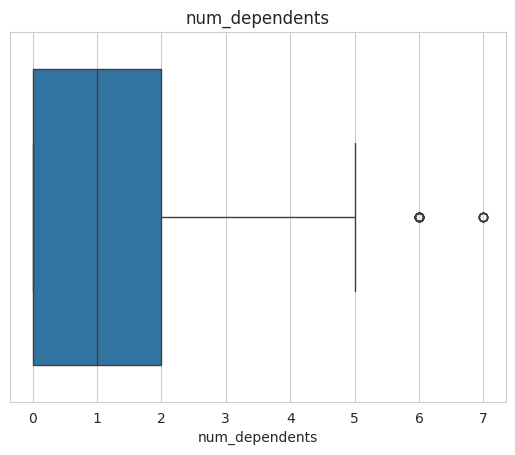

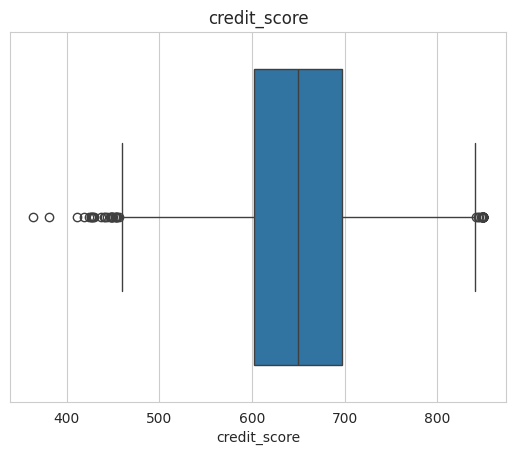

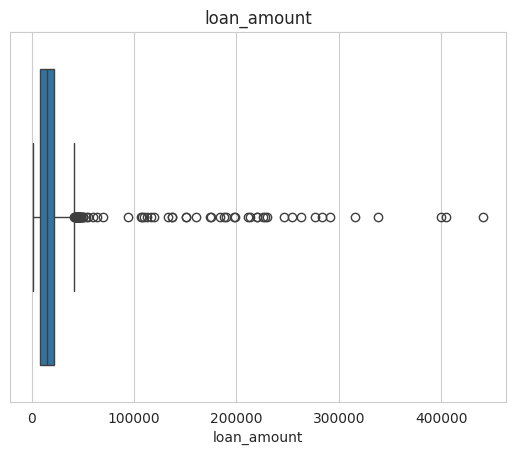

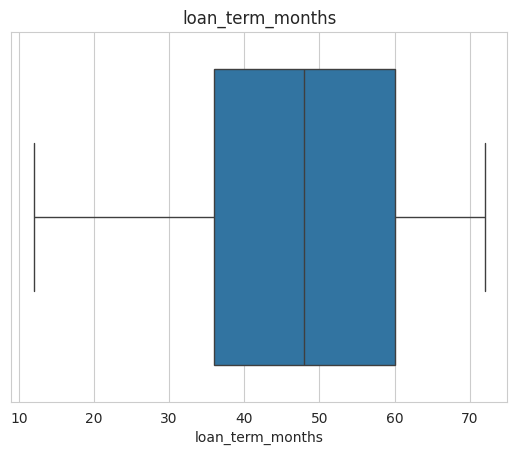

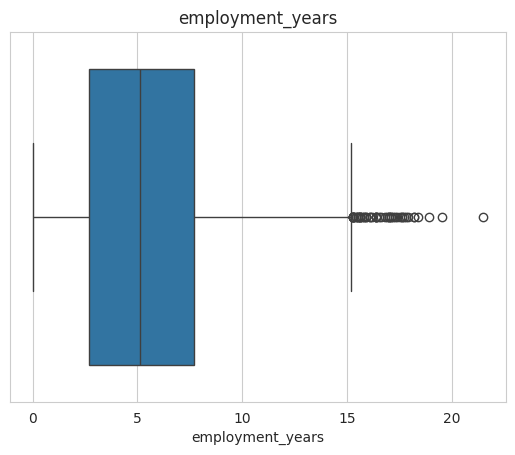

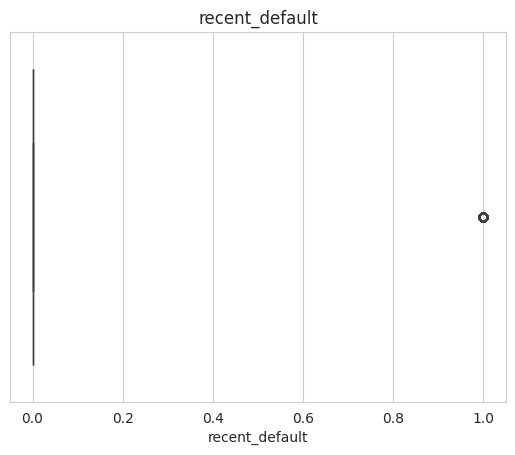

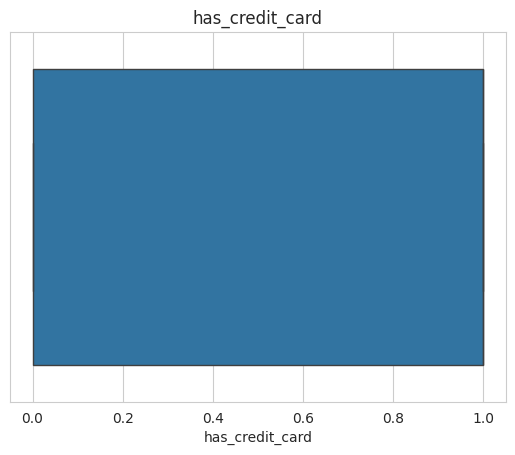

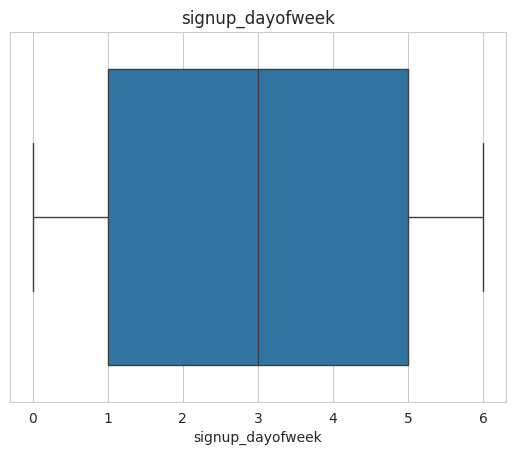

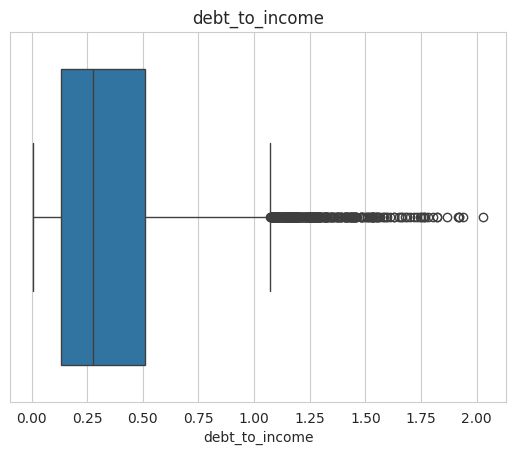

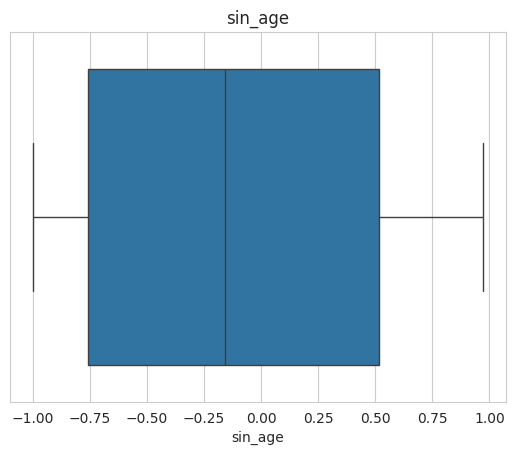

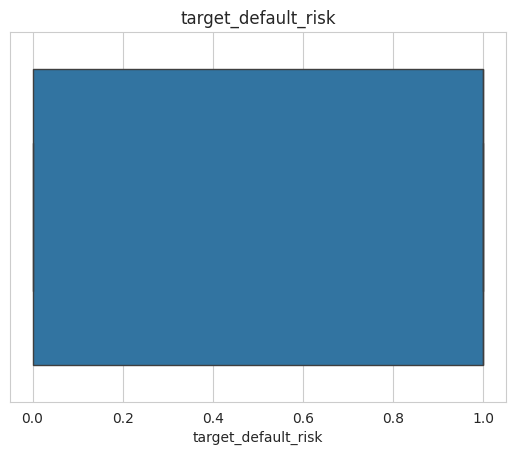

In [ ]:
# Go through each Numeric Column one by one, since we have many columns instead of writing code 10 times, loop does it automatically

for col in num_cols:
  sns.boxplot(x=df[col]) # Draw box plot for these columns
  plt.title(col) # Add column name as tittle
  plt.show() # Display the plot


# Handling Outliers- income, Savings, Monthly expenses, Credit score, loan amount, employment years, Debt to income
# How to Cap them? we will limit the extreme values through IQR method= Q3-Q1

#Lower limit = Q1 - 1.5 × IQR
# Upper limit = Q3 + 1.5 × IQR

In [ ]:
# Apply this logic to every numerical column
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])

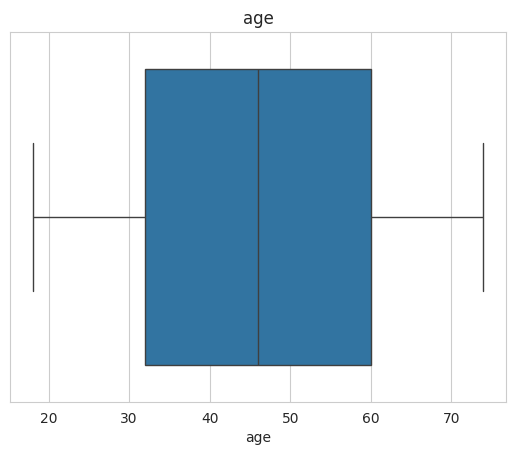

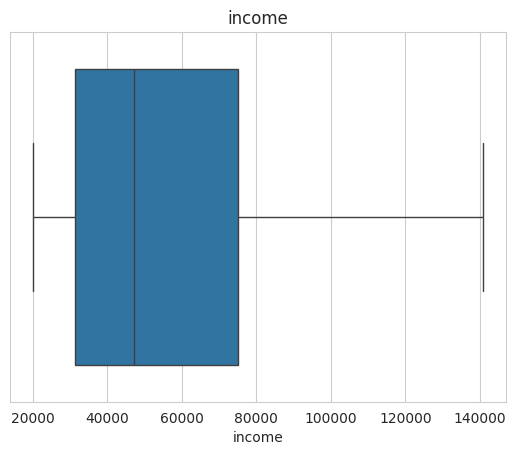

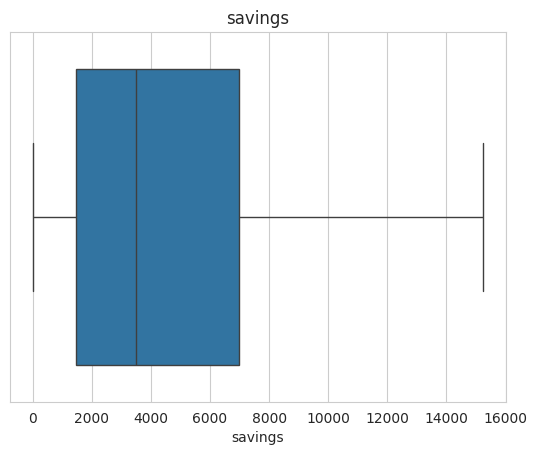

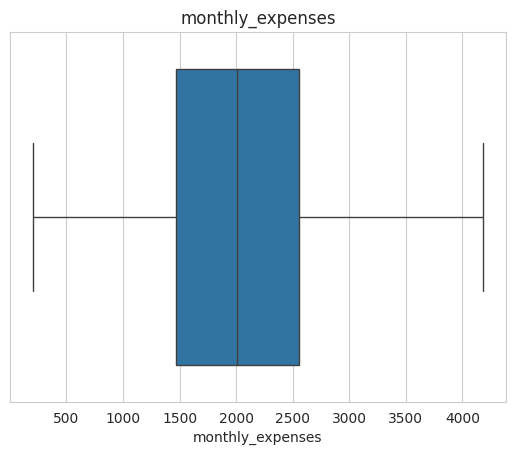

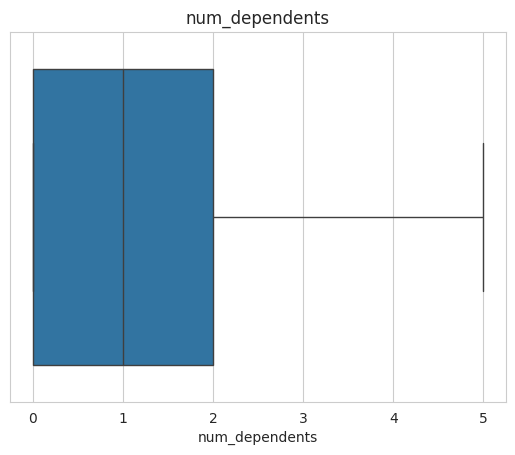

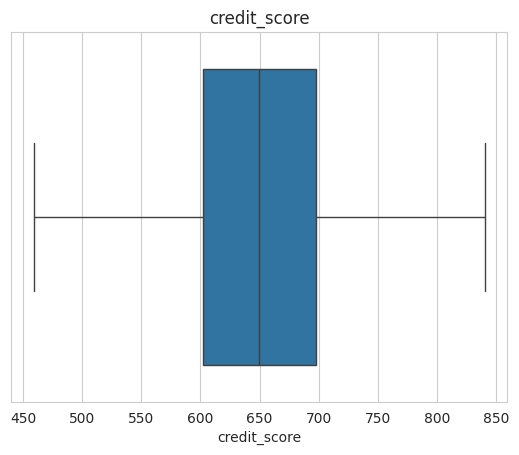

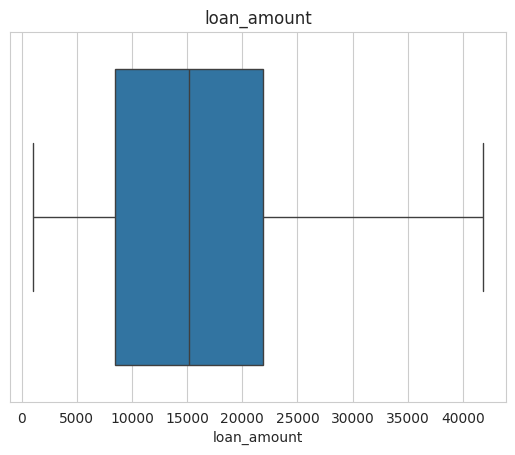

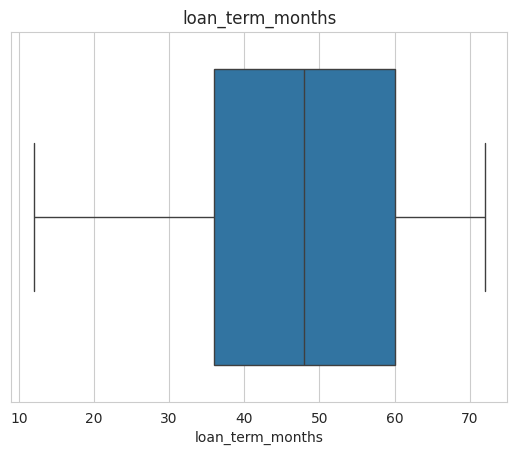

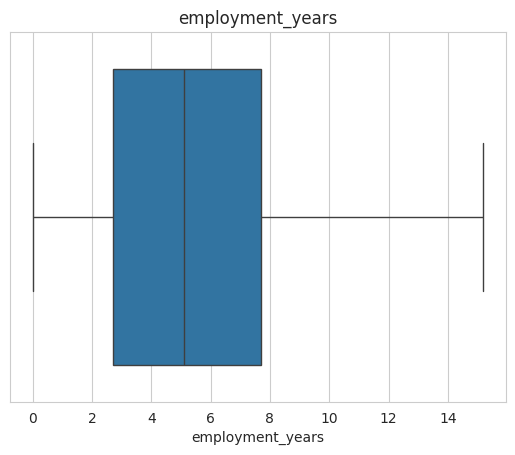

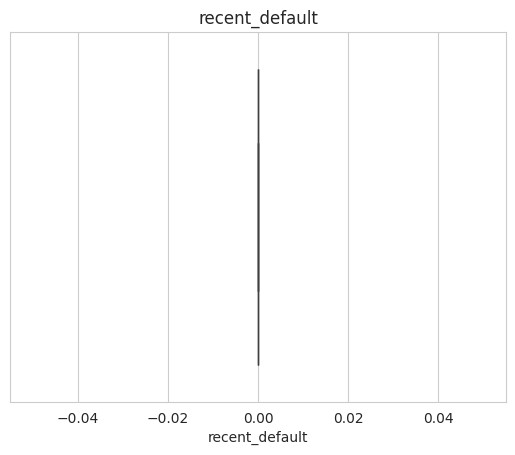

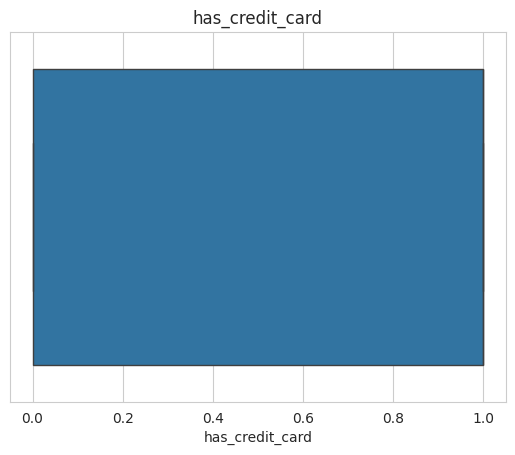

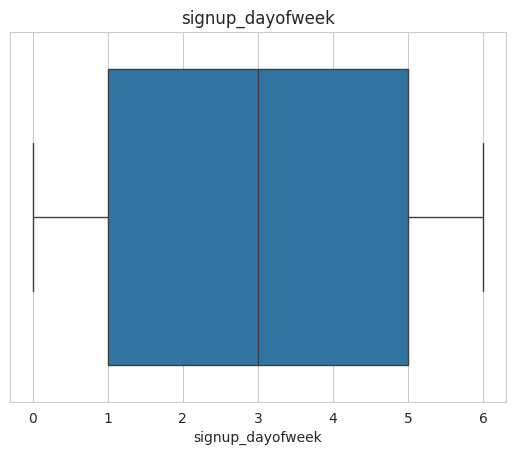

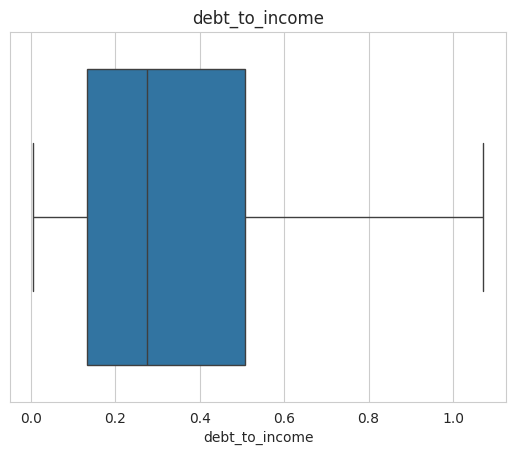

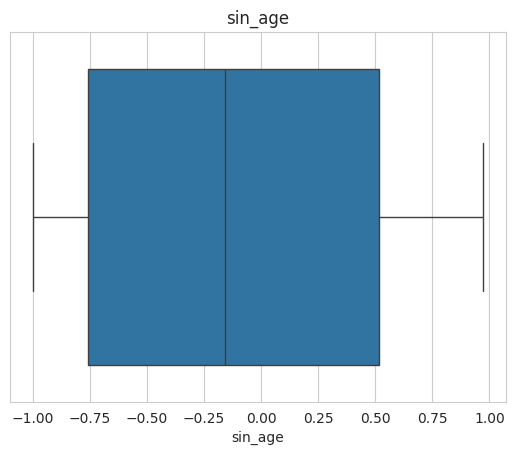

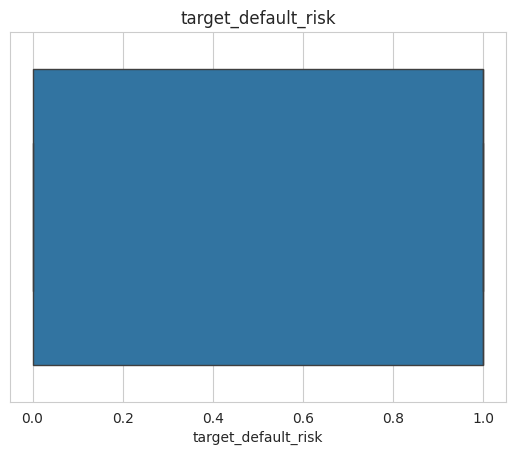

In [ ]:
# now run the box plot again to see the data
for col in num_cols:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

# Handling Missing Values- Imputation fill the missing Values if any
# Separate numeric & categorical columns

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns

# Handle Numeric Missing Values

In [ ]:
from sklearn.impute import SimpleImputer # Import tool for filling missing values

num_imputer = SimpleImputer(strategy='median') #Fill missing values using median

df[num_cols] = num_imputer.fit_transform(df[num_cols]) # Fit means learn and transform mean fill missing values

# Handle Categorical Missing Values- Fill missing text values with most common value

In [ ]:
cat_imputer = SimpleImputer(strategy='most_frequent')

df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

df.isnull().sum() # Check if any missing values are left

,0
customer_id,0
age,0
income,0
savings,0
monthly_expenses,0
num_dependents,0
credit_score,0
loan_amount,0
loan_term_months,0
employment_years,0


# Fix Categorical Errors (Dirty Data Cleaning)- Categorical data = text columns like:education, marital_status,region

In [ ]:
cat_cols = df.select_dtypes(include='object').columns # Show me all text columns
cat_cols

Index(['customer_id', 'home_ownership', 'education', 'marital_status',
       'region', 'signup_date'],
      dtype='object')

In [ ]:
for col in cat_cols: # Check Unique values, For each column, it shows:All possible values
    print(col)
    print(df[col].unique())
    print("------")

customer_id
['CUST006253' 'CUST004685' 'CUST001732' ... 'CUST005391' 'CUST000861'
 'CUST007271']
------
home_ownership
['RENT' 'OWN' 'MORTGAGE' 'OTHER']
------
education
['HS' 'Bachelors' 'Masters' 'Other' 'PhD' 'Bachlors']
------
marital_status
['Single' 'Married' 'Divorced' 'Widowed']
------
region
['West' 'East' 'South' 'North']
------
signup_date
['05-07-2020' '03-10-2018' '30-05-2018' ... '16-12-2018' '03-08-2021'
 '21-02-2019']
------


# Fix errors (Example)- Replace wrong spellings with correct one

In [ ]:
df['education'] = df['education'].replace({
    'Bachlors': 'Bachelors'
})

In [ ]:
df = df.drop('customer_id', axis=1)

KeyError: "['customer_id'] not found in axis"

In [ ]:
# Remove hidden spaces
for col in cat_cols:
    df[col] = df[col].str.strip()

KeyError: 'customer_id'

# Convrt the Text into the numbers- Encoding
get_dummies() → converts text to numbers,
columns=cat_cols → apply on categorical columns,
drop_first=True → avoid duplicate columns

In [ ]:
cat_cols = df.select_dtypes(include='object').columns


In [ ]:
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

KeyError: "None of [Index(['home_ownership', 'education', 'marital_status', 'region',\n       'signup_date'],\n      dtype='object')] are in the [columns]"

# Feature scalling
ML models (especially Logistic Regression & SVM) get confused:Income is huge → more important wrong assumption, so we need to bring features to the same scale
example- Income 50000= 1.5, age= 0.2

In [ ]:
# Define the Target
X = df.drop('target_default_risk', axis=1)
y = df['target_default_risk']

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [ ]:
# Always see 80% to 20% split
print(X_train.shape)
print(X_test.shape)

(8000, 2008)
(2000, 2008)


# Build the first model, Logistic Regression, Will customer default or not?” (Yes/No)

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression() # Create empty model

lr.fit(X_train, y_train) #

LogisticRegression()

# Model Evalution

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8175
[[809 160]
 [205 826]]
              precision    recall  f1-score   support

         0.0       0.80      0.83      0.82       969
         1.0       0.84      0.80      0.82      1031

    accuracy                           0.82      2000
   macro avg       0.82      0.82      0.82      2000
weighted avg       0.82      0.82      0.82      2000



In [ ]:
print(confusion_matrix(y_test, y_pred))

[[809 160]
 [205 826]]
